In this notebook, we simulate and analyse thermal unfolding curves of a protein dimer obtained at different protein concentrations.
We assume that the underlying model is a two-state reversible unfolding: N2 <-> 2U, where N2 is the native dimer and U is the unfolded monomer.

In this example, higher protein concentration should result in a higher apparent melting temperature.

In [10]:
from pychemelt.utils.plotting import plot_unfolding
from pychemelt.thermal_oligomer import ThermalOligomer
from pychemelt.utils.math import linear_baseline, exponential_baseline

from pychemelt.utils.signals import (
    map_two_state_model_to_signal_fx
)

import numpy as np

In [70]:
RNG_SEED = 2
TEMP_START = 25
TEMP_STOP = 90
N_TEMPS = 90
CONCS = np.array([1,2,4,8,16,32,64,128])*1e-6

DHm_VAL = 200
Tm_VAL = 70
CP0_VAL = 2

INTERCEPT_N = 24
SLOPE_N = -0.27
C_N_VAL = 0
INTERCEPT_U = -4
SLOPE_U = 80.5
EXPONENT_U = 0.0224
C_U_VAL = 0

rng = np.random.default_rng(RNG_SEED)

def_params = {
    'dHm': DHm_VAL,
    'Tm': Tm_VAL+273.15,
    'Cp': CP0_VAL,
    'p1_N': C_N_VAL,
    'p2_N': INTERCEPT_N,
    'p3_N': SLOPE_N,
    'p4_N': 0,
    'p1_U': C_U_VAL,
    'p2_U': INTERCEPT_U,
    'p3_U': SLOPE_U,
    'p4_U': EXPONENT_U,
    'baseline_N_fx':linear_baseline,
    'baseline_U_fx':exponential_baseline

}

def aux_create_pychem_sim(params,concs, model, normalise=False):

    signal_fx = map_two_state_model_to_signal_fx(model)

    # Calculate signal range for proper y-axis scaling
    temp_range  = np.linspace(TEMP_START, TEMP_STOP, N_TEMPS)
    temp_range_K = temp_range + 273.15

    signal_list = []
    temp_list   = []

    # Use a seeded Generator for reproducible noise in tests
    rng = np.random.default_rng(2)

    for C in concs:

        y = signal_fx(temp_range_K, C, **params)

        # Add gaussian error to signal
        y += rng.normal(0, 0.0025*1e-3, len(y)) # Small error (seeded)

        # Simulate variance across positions - by introducing a scaling factor (one per curve)
        factor = np.random.uniform(0.92, 1.08) # Random factor between 0.92 and 1.08 (seeded)

        y *= factor

        signal_list.append(y)
        temp_list.append(temp_range)

    pychem_sim = ThermalOligomer()

    pychem_sim.set_model(model)

    pychem_sim.signal_dic['Fluo'] = signal_list
    pychem_sim.temp_dic['Fluo']   = [temp_range for _ in range(len(concs))]

    pychem_sim.conditions = concs

    pychem_sim.global_min_temp = np.min(temp_range)
    pychem_sim.global_max_temp = np.max(temp_range)

    pychem_sim.set_concentrations()

    pychem_sim.set_signal(['Fluo'])

    pychem_sim.select_conditions(normalise_to_global_max=normalise)
    pychem_sim.expand_multiple_signal()

    pychem_sim.estimate_baseline_parameters(
        native_baseline_type='linear',
        unfolded_baseline_type='exponential'
    )

    pychem_sim.n_residues = 80  # only for cp initial guess
    pychem_sim.guess_Cp()

    return pychem_sim

In [72]:
dimer_sim = aux_create_pychem_sim(def_params, concs, "Dimer")
fig = plot_unfolding(dimer_sim)
fig.show()

In [73]:
dimer_sim.estimate_derivative()
fig_derivative = plot_unfolding(dimer_sim, plot_derivative=True)
fig_derivative.show()

Apparent Tms (°C): [np.float64(57.13483146067416), np.float64(57.86516853932584), np.float64(58.59550561797753), np.float64(58.59550561797753), np.float64(59.325842696629216), np.float64(59.325842696629216), np.float64(59.325842696629216)]


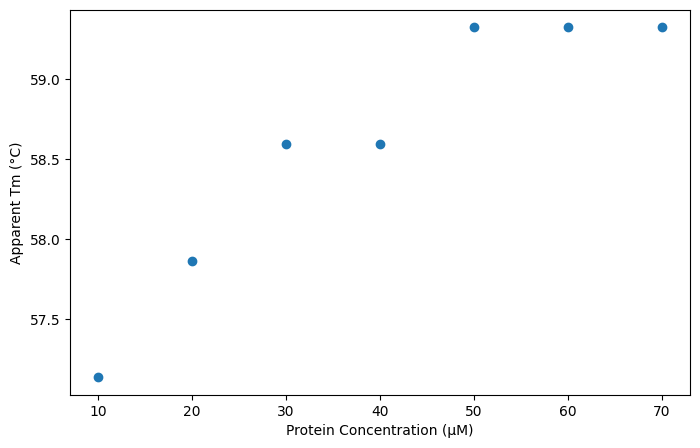

In [74]:
# Calculate apparent Tms from the first derivative of the unfolding curves
dimer_sim.guess_Tm()
apparent_tms = dimer_sim.t_melting_init_multiple[0]

print("Apparent Tms (°C):", apparent_tms)

# plot Tms as a function of concentration
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.scatter(dimer_sim.conditions*1e6, apparent_tms, marker='o')
plt.xlabel('Protein Concentration (µM)')
plt.ylabel('Apparent Tm (°C)')
plt.show()

Now we proceed to fit the data with local intercepts and local slopes.

In [82]:
dimer_sim.fit_thermal_unfolding_global()
print("Fitted parameters:")
print(dimer_sim.params_df.head())
fig = plot_unfolding(dimer_sim)
fig.show()

Fitted parameters:
                                          Parameter       Value  \
0                                           Tm (°C)   69.991743   
1                                     ΔH (kcal/mol)  200.232777   
2                                  Cp (kcal/mol/°C)    2.008972   
3   intercept_native - 9.999999999999999e-06 - Fluo   22.383311   
4  intercept_native - 1.9999999999999998e-05 - Fluo   22.469254   

   Relative error (%)  Fitting low Bound  Fitting high Bound  
0            0.047599          57.991743           88.595506  
1            0.511494          10.000000          500.000000  
2            4.836785           0.100000            5.000000  
3            0.346124           0.022349        22348.673525  
4            0.171594           0.022406        22406.081288  


Now we proceed to fit the data with local intercepts and global slopes

In [86]:
dimer_sim.params_df = None
dimer_sim.fit_thermal_unfolding_global()
dimer_sim.fit_thermal_unfolding_global_global()
print("Fitted parameters:")
print(dimer_sim.params_df.head())
fig = plot_unfolding(dimer_sim)
fig.show()

Fitted parameters:
                                          Parameter       Value  \
0                                           Tm (°C)   69.688588   
1                                     ΔH (kcal/mol)  208.992366   
2                                  Cp (kcal/mol/°C)    2.797156   
3   intercept_native - 9.999999999999999e-06 - Fluo   22.482815   
4  intercept_native - 1.9999999999999998e-05 - Fluo   22.587870   

   Relative error (%)  Fitting low Bound  Fitting high Bound  
0            0.132844          57.688588           88.595506  
1            1.433499          10.000000          500.000000  
2           10.681267           0.100000            5.000000  
3            0.548534           0.022349        22348.673525  
4            0.277211           0.022406        22406.081288  


Now we proceed to fit the data with global intercepts and global slopes

In [88]:
dimer_sim.params_df = None
dimer_sim.fit_thermal_unfolding_global()
dimer_sim.fit_thermal_unfolding_global_global()
dimer_sim.fit_thermal_unfolding_global_global_global()
print("Fitted parameters:")
print(dimer_sim.params_df.head())
print(dimer_sim.params_df.tail())
fig = plot_unfolding(dimer_sim)
fig.show()

Fitted parameters:
                   Parameter       Value  Relative error (%)  \
0                    Tm (°C)   69.987510            0.043698   
1              ΔH (kcal/mol)  200.388872            0.467487   
2           Cp (kcal/mol/°C)    2.025677            4.373444   
3    intercept_native - Fluo   24.161362            0.032481   
4  intercept_unfolded - Fluo   -4.018601            3.643925   

   Fitting low Bound  Fitting high Bound  
0          57.688588           88.595506  
1          10.000000          500.000000  
2           0.100000            5.000000  
3           0.222131         2221.307351  
4        -656.551063           -0.065655  
                                           Parameter     Value  \
10   Scale factor - 9.999999999999999e-06 (M). ID: 0  0.926386   
11  Scale factor - 1.9999999999999998e-05 (M). ID: 1  0.929811   
12  Scale factor - 2.9999999999999997e-05 (M). ID: 2  0.943413   
13  Scale factor - 4.9999999999999996e-05 (M). ID: 4  0.957055   
14  Scal